In [3]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"


import sys

sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")

import jaxsp as jsp

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from jaxsp.constants import GN, hbar

import Stellar_sim_funcs as SSF

from collections import defaultdict

from scipy.special import sph_harm_y


sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Tests/Testing_sim_methods")

import gaunt_funcs as gf

import s2fft

m22 = 3
u = jsp.set_schroedinger_units(m22)
r_min = 20 * u.from_pc
r_max_enclosing_frac = 0.99
no_radius_bins = 1000

In [4]:
def precompute_lm_pairs_Ylms(l):

    '''Precompute (l, m) pair for spherical harmonics'''

    lm_l = []      # list of l for each mode k
    lm_m = []      # list of m for each mode k
    parent_j = []  # which radial eigenstate j this (l,m) mode comes from
    lm_pairs_dict = defaultdict(int)

    for j_idx, ell in enumerate(l.tolist()):
        for m in range(-ell, ell + 1):
            lm_l.append(ell)
            lm_m.append(m)
            parent_j.append(j_idx)
            lm_pairs_dict[(ell, m)] += 1

    lm_pairs_list = list(lm_pairs_dict.keys())       # unique (l,m) tuples, insertion order
    lm_pairs = jnp.array(lm_pairs_list)              # (N_unique_lm, 2)

    # Map each mode k -> index into lm_pairs_list (its unique (l,m) slot).
    lm_to_idx = {pair: i for i, pair in enumerate(lm_pairs_list)}
    lm_idx_per_mode = jnp.array(
        [lm_to_idx[(ell, m)] for ell, m in zip(lm_l, lm_m)], dtype=jnp.int32)


    '''Precompute Y_lm's for wavefunction reconstruction'''

    # McEwen-Wiaux-style equiangular grid.
    # Y_lm depends only on (l,m), NOT on the parent radial eigenstate j, so we
    # store one slice per unique (l,m) — shape (N_unique_lm, n_theta, n_phi) —
    # and let downstream code index via lm_idx_per_mode when it needs per-mode
    # values. For l_max in the 70s this is a ~20x device-memory reduction vs
    # the old (Nmodes, n_theta, n_phi) layout, which duplicated each Y_lm
    # across every j that carries that (l,m).
    # Store as complex64 to halve transfer size and device storage.
    # NOTE: with jax_enable_x64=True, einsum(aj[c128] * Y_lm[c64]) promotes to
    # complex128; to realise the GPU-memory win at runtime, also cast aj and
    # R_j_r_phased to complex64 at the use sites.

    L = int(max(l)) + 1

    L_max_out = 2 * L - 1

    n_theta = L_max_out
    n_phi = 2 * L_max_out - 1

    i = np.arange(n_theta)
    theta_np = (np.pi * (2 * i + 1)) / (2 * L_max_out - 1)
    j = np.arange(n_phi)
    phi_np = (2 * np.pi * j) / (2 * L_max_out - 1)

    Theta, Phi = np.meshgrid(theta_np, phi_np, indexing="ij")  # both (n_theta, n_phi), numpy

    Y_lm_np = np.empty((len(lm_pairs_list), n_theta, n_phi), dtype=np.complex128)
    for u, (ell, m) in enumerate(lm_pairs_list):
        Y_lm_np[u] = sph_harm_y(ell, m, Theta, Phi)

    Y_lm = jnp.asarray(Y_lm_np)  # single host->device transfer, complex64

    return (jnp.array(parent_j), Y_lm, lm_pairs,
            jnp.array(lm_l), jnp.array(lm_m),
            jnp.asarray(theta_np), jnp.asarray(phi_np),
            lm_idx_per_mode)


def _compute_all_phi(rho_lm, r, output_lm_pairs, L_max_out, G):
    """
    Vmapped computation of dphi_dr and phi_lm for all (l,m) pairs.
    All args are JAX arrays
    """
    Nr = rho_lm.shape[0] - 1
    dr     = jnp.diff(r)
    dr_rev = jnp.diff(r[::-1])

    def compute_phi_for_lm(lm_pair):
        l_val = lm_pair[0]
        m_val = lm_pair[1]
        prefix = -4.0 * jnp.pi * G / (2 * l_val + 1)
        m_ind  = m_val + L_max_out - 1

        f_at_lm = rho_lm[:, l_val, m_ind]

        integrand_ext = r ** (1 - l_val) * f_at_lm
        integrand_int = r ** (l_val + 2) * f_at_lm

        avg_int = 0.5 * (integrand_int[1:] + integrand_int[:-1])
        integral_int = jnp.concatenate([jnp.array([0.0]), jnp.cumsum(avg_int * dr)])


        integrand_ext_rev = integrand_ext[::-1]
        avg_ext = 0.5 * (integrand_ext_rev[1:] + integrand_ext_rev[:-1])
        integral_ext = jnp.concatenate([-jnp.cumsum(avg_ext * dr_rev)[::-1], jnp.array([0.0])])


        dphi_lm_dr = prefix * (l_val * r ** (l_val - 1) * integral_ext
                            - (l_val + 1) * r ** (-l_val - 2) * integral_int)
        phi_lm  = prefix * (r ** l_val * integral_ext
                            + r ** (-l_val - 1) * integral_int)
        return dphi_lm_dr, phi_lm

    return jax.vmap(compute_phi_for_lm)(output_lm_pairs)



cNFWtides_params = jnp.array([
357964808.148399 * u.from_Msun,
25.690207,
0.407461,
0.012670 * u.from_Kpc,
1.857991 * u.from_Kpc,
3.729259
])

density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

N = 512
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)

eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

N = 1024
a = 1
b = 10

rmax = jsp.enclosing_radius(0.99, density_params)
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)

l = eigenstate_lib.radial_eigenmode_params.l

eigen_energies = eigenstate_lib.radial_eigenmode_params.E


print('l max from jaxsp:', max(l))
L = int(max(l) + 1)


rmin = 20 * u.from_pc


tol = 1e-7
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)

total_mass = wavefunction_params.total_mass


aj_2 = wavefunction_params.aj_2        # shape (Nj,)


parent_j, Y_lm, lm_pairs, lm_l_per_mode, lm_m_per_mode, theta, phi, lm_idx_per_mode = precompute_lm_pairs_Ylms(l)


lm_l = lm_pairs[:, 0]        # unique pairs — used for Gaunt table
lm_m = lm_pairs[:, 1]

Nmodes = len(parent_j)
rand_phase_per_mode = jax.random.uniform(jax.random.PRNGKey(42), shape=(Nmodes,), minval=0.0, maxval=2 * jnp.pi)
aj = jnp.sqrt(aj_2[parent_j]) * jnp.exp(1j * rand_phase_per_mode)  # shape (Nmodes,)




def construct_rho_lms(aj, parent_j, R_j_r_phased, total_mass, L_max_out, gaunt_table, lm_idx_sorted_per_mode):

    # Use precomputed R_j_r_phased (set once per macro timestep in run_simulation)
    # to avoid recomputing exp(-i E t / hbar) on every call.
    aj_modes = aj  # already (Nmodes,) with independent phases


    rho_lm_gaunt = gf.compute_rho_lm_gaunt(aj_modes, R_j_r_phased, parent_j, lm_idx_sorted_per_mode,
        total_mass, L_max_out, gaunt_table, batch_size = 100_000)

    return rho_lm_gaunt

def forward_s2fft(rho_rtp, L_max_out):

    '''Forward s2fft of 3d density to get rho_lm(r)
    '''

    #Parallel forward SHT over all radii
    def forward_sht_single_r(rho_at_r):
        return s2fft.forward(rho_at_r, L_max_out, sampling='mw', method='jax')

    flm_r = jax.vmap(forward_sht_single_r)(rho_rtp)  # (Nr, L, 2*L-1)


    return flm_r

def construct_rho_rtp(R_j_r_phased, aj, parent_j, Y_lm, lm_idx_per_mode):
    R_modes = R_j_r_phased[:, parent_j]
    c_lm = jnp.zeros((Y_lm.shape[0], R_j_r_phased.shape[0]), dtype=aj.dtype).at[lm_idx_per_mode].add(aj[:, None] * R_modes.T)   # (N_unique_lm, Nr)
    full_psi_rtp = jnp.einsum('ur,utp->rtp', c_lm, Y_lm)

    rho_rtp = total_mass * jnp.abs(full_psi_rtp) ** 2
    return rho_rtp



#print(f"Precomputation of (l,m) pairs and Y_lm grid completed in {end - start:.2f} seconds")

L_max_out = 2 * L - 1  # captures all density harmonics up to l1+l2 <= 2*(L-1)


if m22 == 1:
    # Precompute Gaunt table ONCE — reuse this across all time steps
    gaunt_table = gf.precompute_gaunt_table(lm_l, lm_m, L_max_out)

    _, _, _, _, unique_lm = gaunt_table
    scatter_matrix = gf.make_scatter_matrix(lm_l_per_mode, lm_m_per_mode, unique_lm)

l max from jaxsp: 71


In [5]:
no_time_steps = 1000
total_evolve_time = 10
dt = (total_evolve_time * u.from_Gyr) / no_time_steps


In [6]:
no_bins = 1800

# r_truth is the 1800-bin grid used for phi_lm_2000
r_truth = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), no_bins)

print(f'Truth test using {no_bins} radius bins')
r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), int(no_bins))


R_j_r_fixed = eval_library(r, eigenstate_lib.radial_eigenmode_params)  # (Nr, Nj)

print(R_j_r_fixed.shape)  # (Nr, Nj)


phase = jnp.exp(-1j * eigen_energies * 1 * dt / 1)
R_j_r_phased = R_j_r_fixed * phase[None, :]

out_lm = [(L, M) for L in range(L_max_out) for M in range(-L, L+1)]
output_lm_pairs = jnp.array(out_lm)

if m22 == 1:
    # 1. Construct total psi and rho on background grid
    rho_lms = construct_rho_lms(aj, parent_j, R_j_r_phased, total_mass, L_max_out, gaunt_table, lm_idx_per_mode)
    print(rho_lms.shape)  # (Nr, L, 2L-1)

rho_rtp = construct_rho_rtp(R_j_r_phased, aj, parent_j, Y_lm, lm_idx_per_mode)

rho_lms_s2fft = forward_s2fft(rho_rtp, L_max_out)


G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

if m22 == 1:
    dphi_lm_2000, phi_lm_2000 = _compute_all_phi(rho_lms, r, output_lm_pairs, int(L_max_out), G)

else:
    dphi_lm_2000, phi_lm_2000 = _compute_all_phi(rho_lms_s2fft, r, output_lm_pairs, int(L_max_out), G)

Truth test using 1800 radius bins
(1800, 2582)


[ 100.  185.  270.  355.  440.  525.  610.  695.  780.  865.  950. 1035.
 1120. 1205. 1290. 1375. 1460. 1545. 1630. 1715. 1800.]
No. radius bins: 100.0


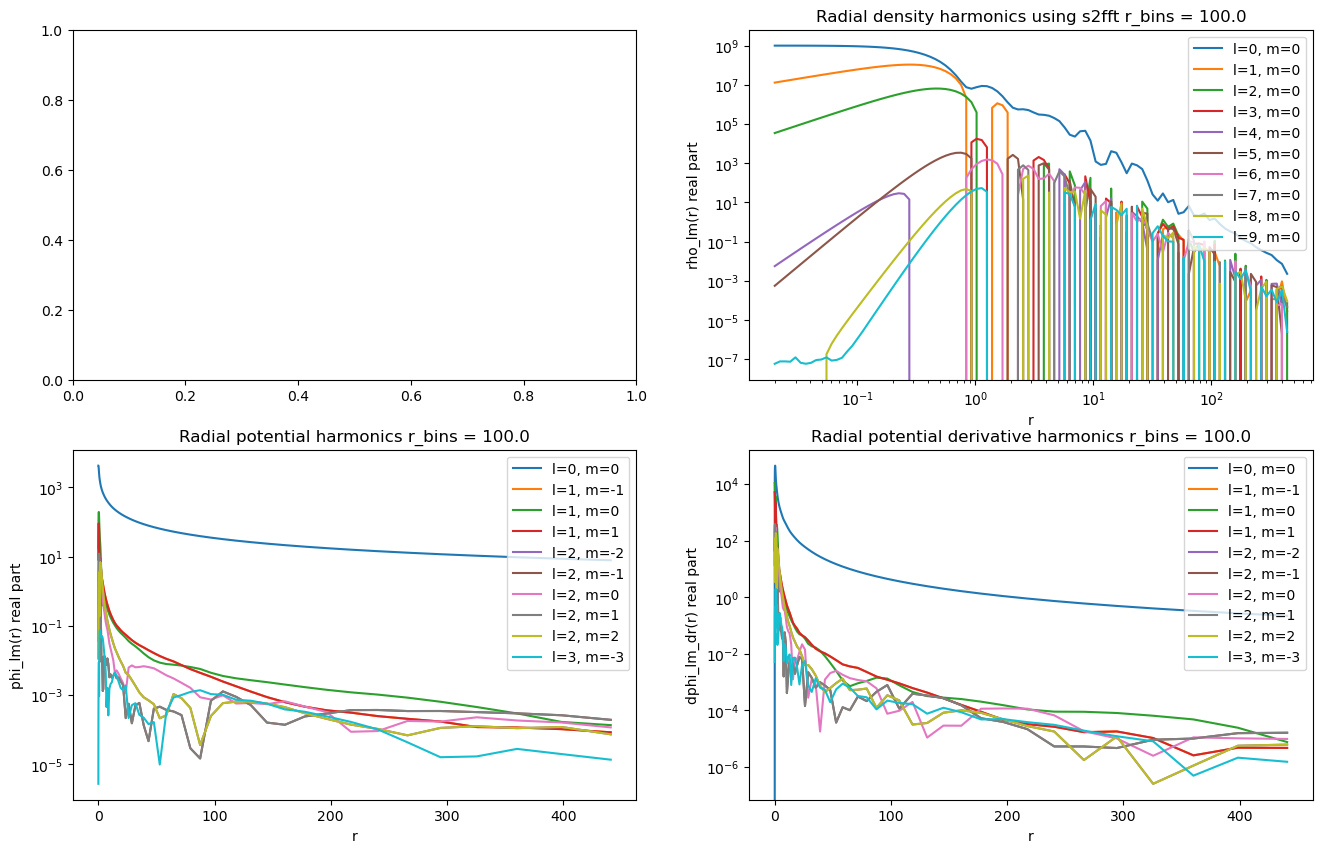

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.3715%
    l=1, m=-1: max err = 28.2930%
    l=1, m=0: max err = 52242.3171%
    l=1, m=1: max err = 28.2930%
    l=2, m=-2: max err = 545.8497%
    l=2, m=-1: max err = 117.1588%
    l=2, m=0: max err = 19485.7227%
    l=2, m=1: max err = 117.1588%
    l=2, m=2: max err = 545.8497%
    l=3, m=-3: max err = 271.9822%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 8.6354%
    l=1, m=-1: max err = 38.2946%
    l=1, m=0: max err = 1568.8451%
    l=1, m=1: max err = 38.2946%
    l=2, m=-2: max err = 1210.9691%
    l=2, m=-1: max err = 321.3917%
    l=2, m=0: max err = 1363.6166%
    l=2, m=1: max err = 321.3917%
    l=2, m=2: max err = 1210.9691%
    l=3, m=-3: max err = 6859.0117%
No. radius bins: 185.0


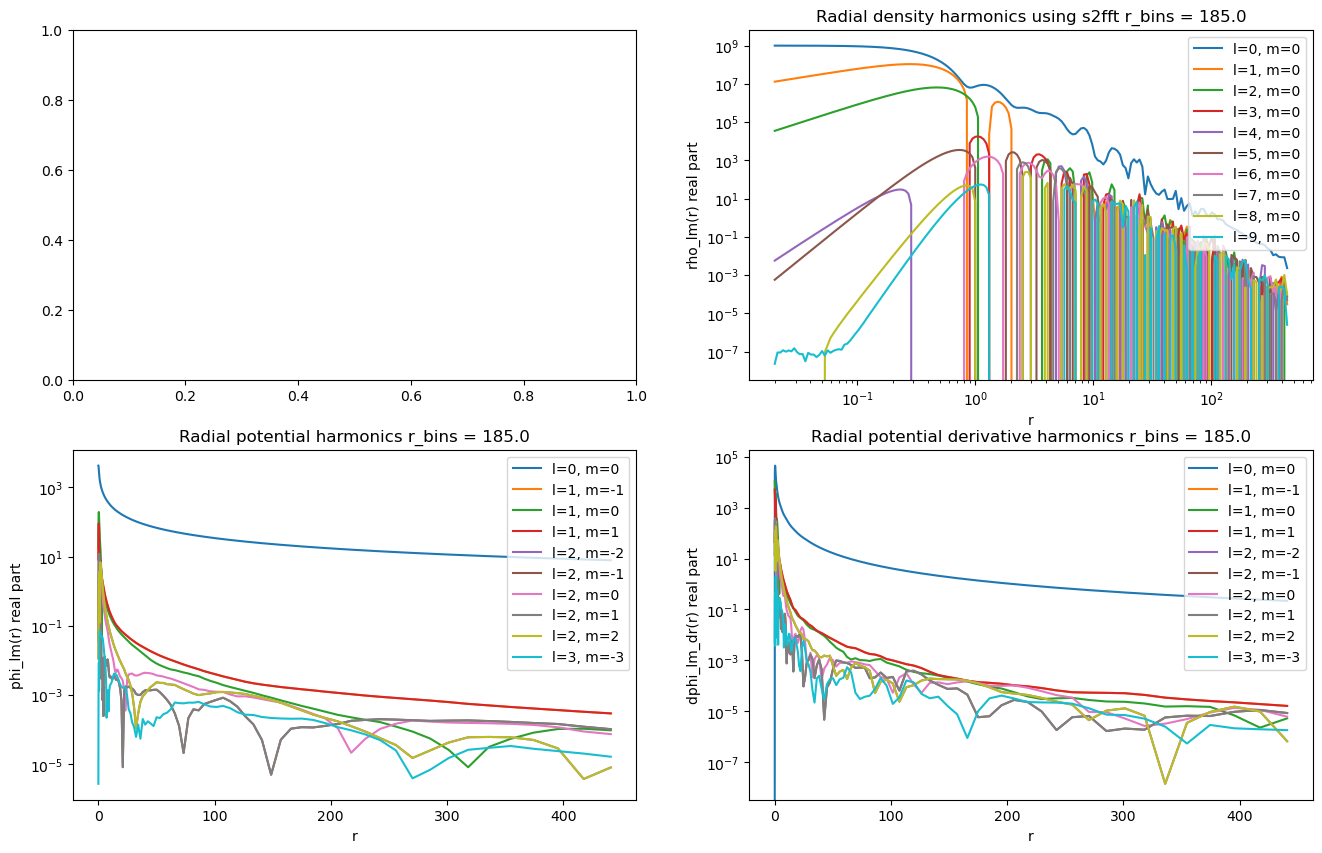

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.1228%
    l=1, m=-1: max err = 35.1498%
    l=1, m=0: max err = 5146.3369%
    l=1, m=1: max err = 35.1498%
    l=2, m=-2: max err = 138.7287%
    l=2, m=-1: max err = 22.2913%
    l=2, m=0: max err = 20320.0405%
    l=2, m=1: max err = 22.2913%
    l=2, m=2: max err = 138.7287%
    l=3, m=-3: max err = 65.1026%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 4.6182%
    l=1, m=-1: max err = 42.6068%
    l=1, m=0: max err = 226.0787%
    l=1, m=1: max err = 42.6068%
    l=2, m=-2: max err = 326.9266%
    l=2, m=-1: max err = 145.6582%
    l=2, m=0: max err = 1071.8571%
    l=2, m=1: max err = 145.6582%
    l=2, m=2: max err = 326.9266%
    l=3, m=-3: max err = 1470.3711%
No. radius bins: 270.0


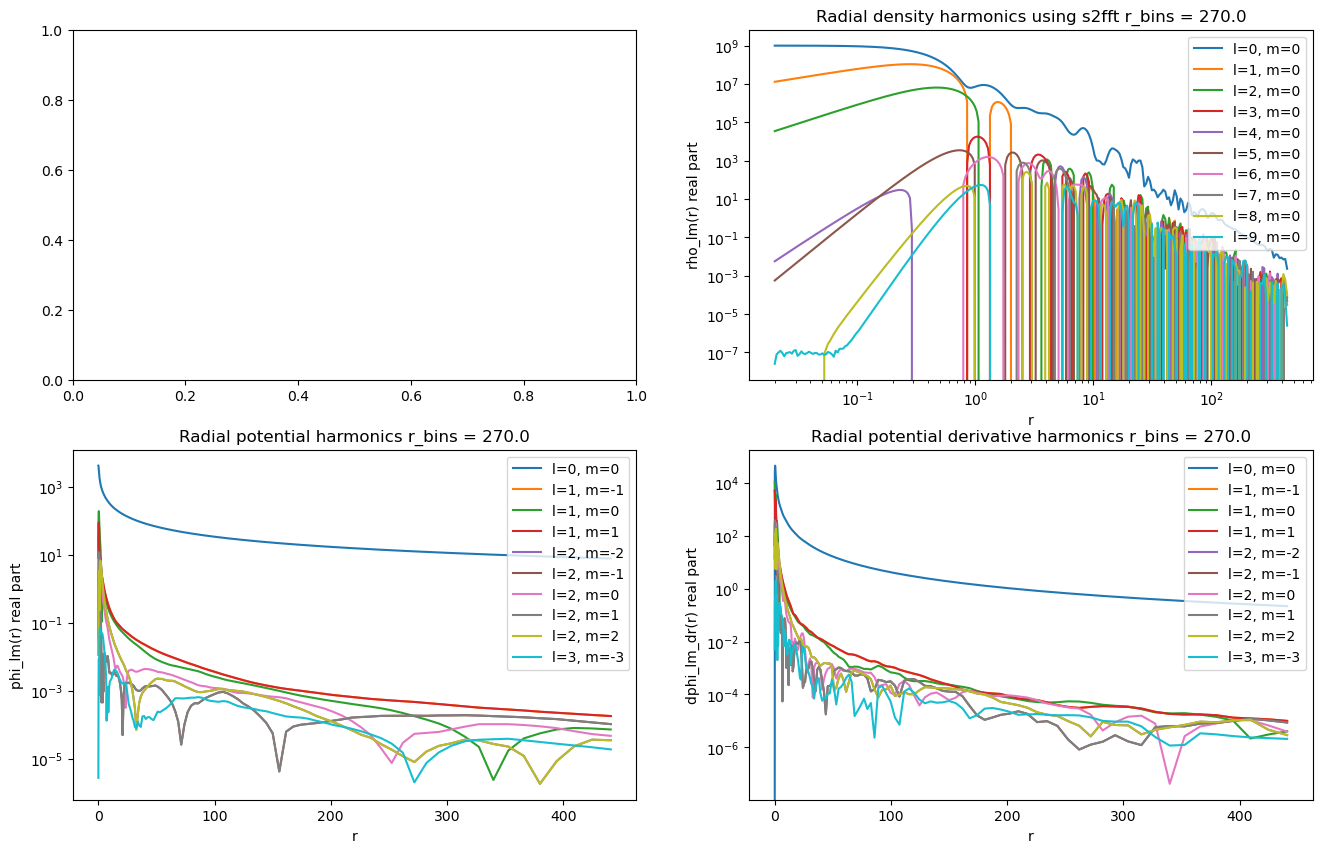

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0561%
    l=1, m=-1: max err = 0.2632%
    l=1, m=0: max err = 99.5747%
    l=1, m=1: max err = 0.2632%
    l=2, m=-2: max err = 15.2296%
    l=2, m=-1: max err = 1.6164%
    l=2, m=0: max err = 159.0386%
    l=2, m=1: max err = 1.6164%
    l=2, m=2: max err = 15.2296%
    l=3, m=-3: max err = 5.4683%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 3.0435%
    l=1, m=-1: max err = 4.2133%
    l=1, m=0: max err = 73.7874%
    l=1, m=1: max err = 4.2133%
    l=2, m=-2: max err = 143.6658%
    l=2, m=-1: max err = 94.7880%
    l=2, m=0: max err = 500.4092%
    l=2, m=1: max err = 94.7880%
    l=2, m=2: max err = 143.6658%
    l=3, m=-3: max err = 1207.7644%
No. radius bins: 355.0


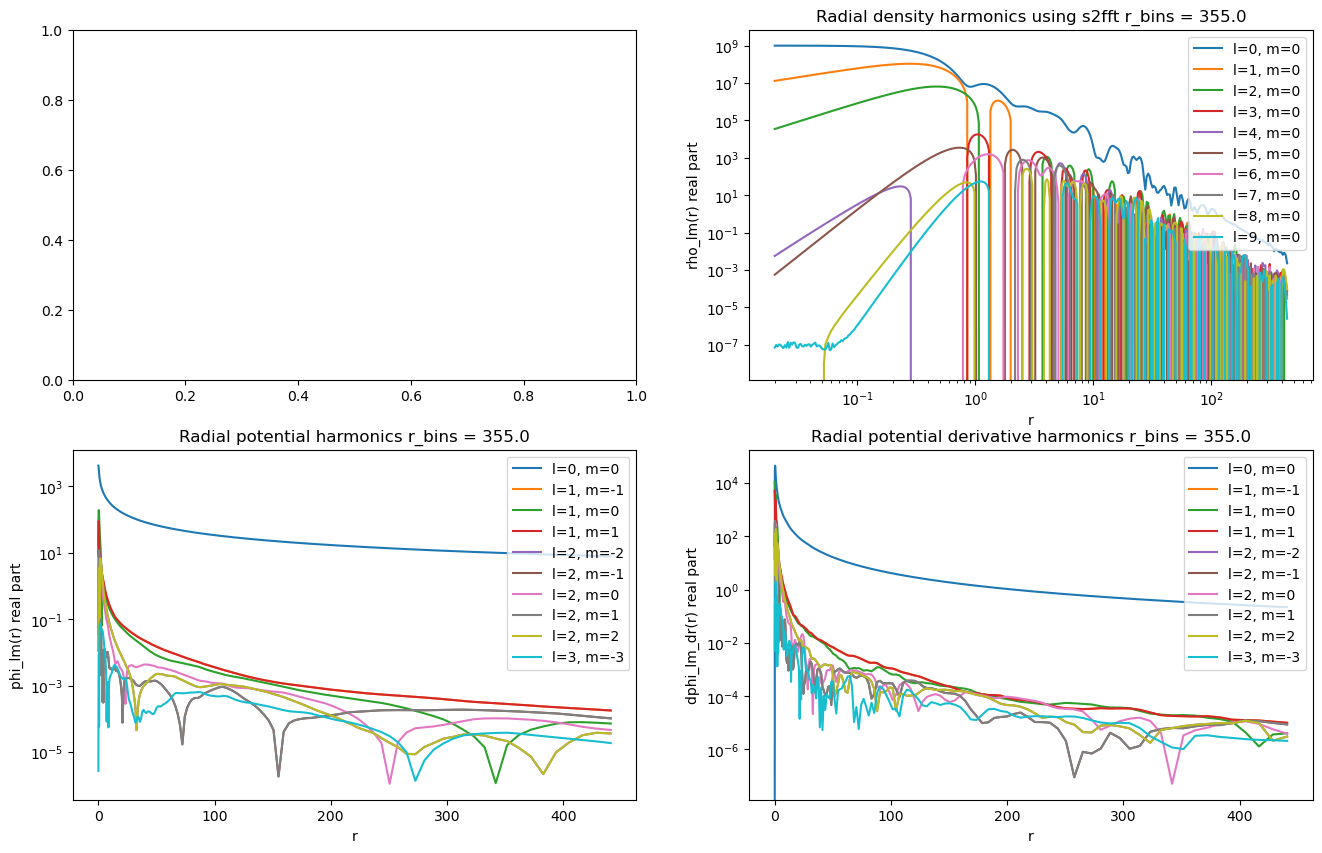

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0323%
    l=1, m=-1: max err = 0.1531%
    l=1, m=0: max err = 49.2129%
    l=1, m=1: max err = 0.1531%
    l=2, m=-2: max err = 9.1458%
    l=2, m=-1: max err = 0.9245%
    l=2, m=0: max err = 50.4182%
    l=2, m=1: max err = 0.9245%
    l=2, m=2: max err = 9.1458%
    l=3, m=-3: max err = 4.2384%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 2.2036%
    l=1, m=-1: max err = 2.9154%
    l=1, m=0: max err = 60.6727%
    l=1, m=1: max err = 2.9154%
    l=2, m=-2: max err = 94.5021%
    l=2, m=-1: max err = 60.0255%
    l=2, m=0: max err = 373.0303%
    l=2, m=1: max err = 60.0255%
    l=2, m=2: max err = 94.5021%
    l=3, m=-3: max err = 765.2847%
No. radius bins: 440.0


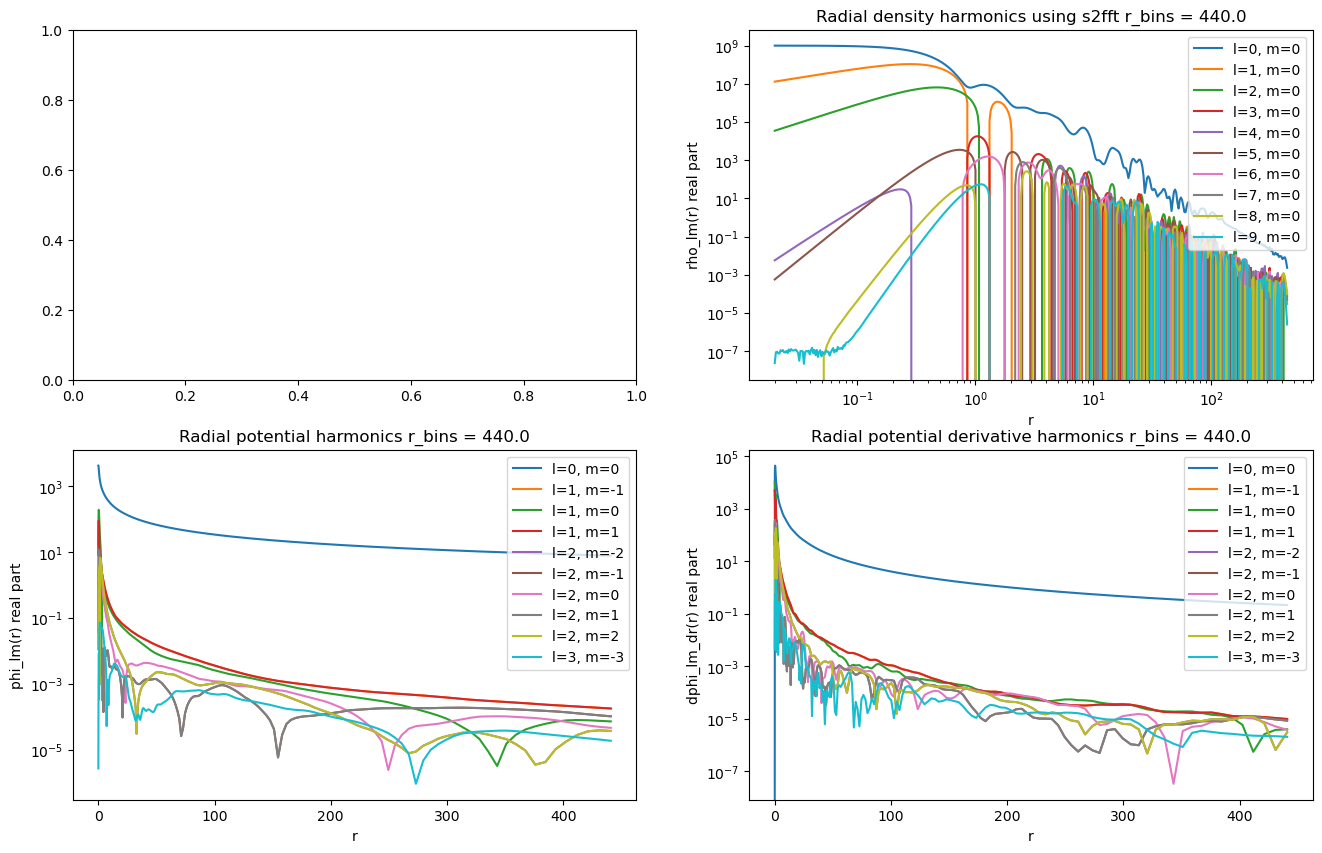

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0208%
    l=1, m=-1: max err = 0.1017%
    l=1, m=0: max err = 35.5223%
    l=1, m=1: max err = 0.1017%
    l=2, m=-2: max err = 5.7842%
    l=2, m=-1: max err = 0.5887%
    l=2, m=0: max err = 14.4415%
    l=2, m=1: max err = 0.5887%
    l=2, m=2: max err = 5.7842%
    l=3, m=-3: max err = 1.9017%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 1.6814%
    l=1, m=-1: max err = 2.1126%
    l=1, m=0: max err = 41.7001%
    l=1, m=1: max err = 2.1126%
    l=2, m=-2: max err = 49.7893%
    l=2, m=-1: max err = 40.5435%
    l=2, m=0: max err = 165.6376%
    l=2, m=1: max err = 40.5435%
    l=2, m=2: max err = 49.7893%
    l=3, m=-3: max err = 480.2871%
No. radius bins: 525.0


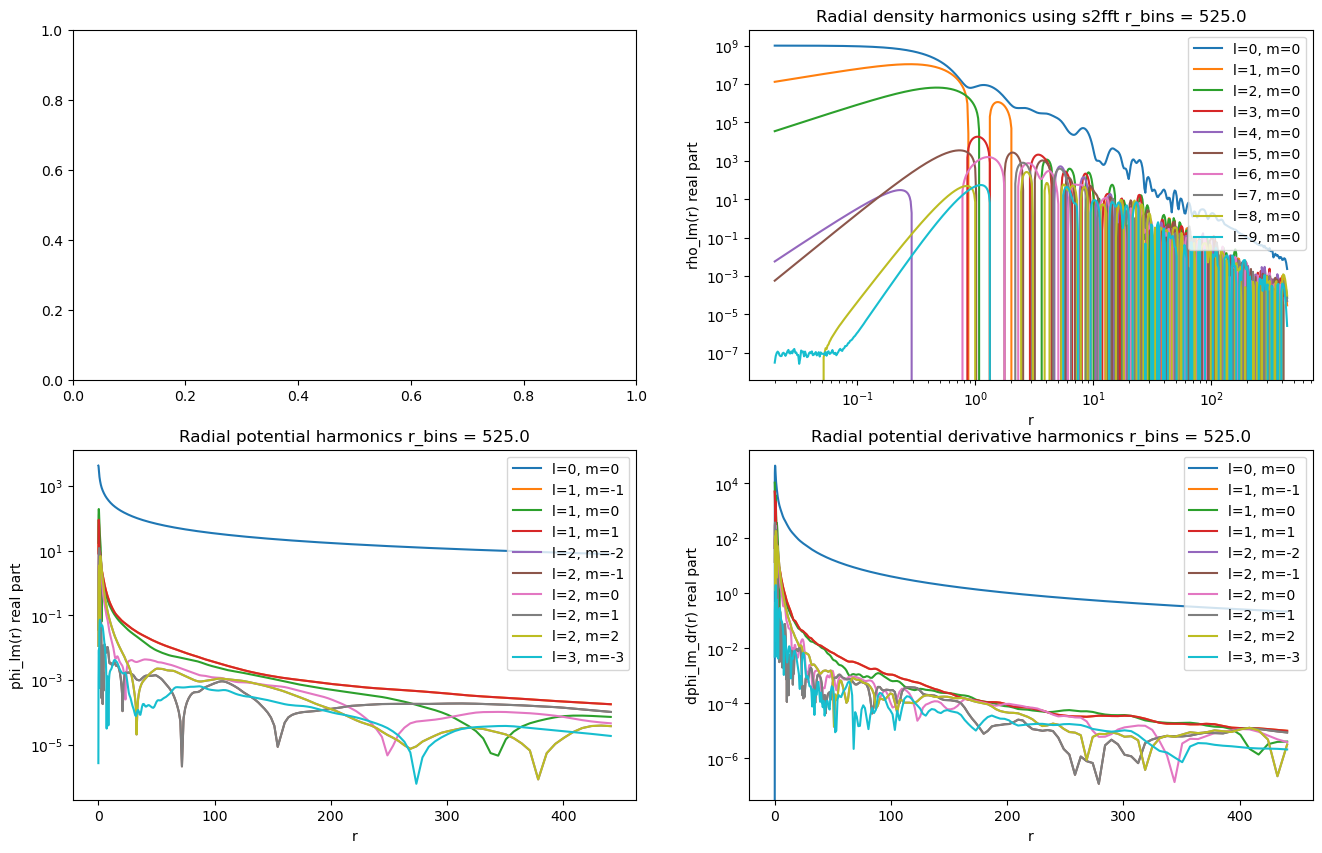

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0146%
    l=1, m=-1: max err = 0.0713%
    l=1, m=0: max err = 25.3360%
    l=1, m=1: max err = 0.0713%
    l=2, m=-2: max err = 3.9132%
    l=2, m=-1: max err = 0.4077%
    l=2, m=0: max err = 22.5164%
    l=2, m=1: max err = 0.4077%
    l=2, m=2: max err = 3.9132%
    l=3, m=-3: max err = 1.5624%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 1.3255%
    l=1, m=-1: max err = 1.6738%
    l=1, m=0: max err = 34.8758%
    l=1, m=1: max err = 1.6738%
    l=2, m=-2: max err = 31.6580%
    l=2, m=-1: max err = 28.8263%
    l=2, m=0: max err = 135.9386%
    l=2, m=1: max err = 28.8263%
    l=2, m=2: max err = 31.6580%
    l=3, m=-3: max err = 298.4299%
No. radius bins: 610.0


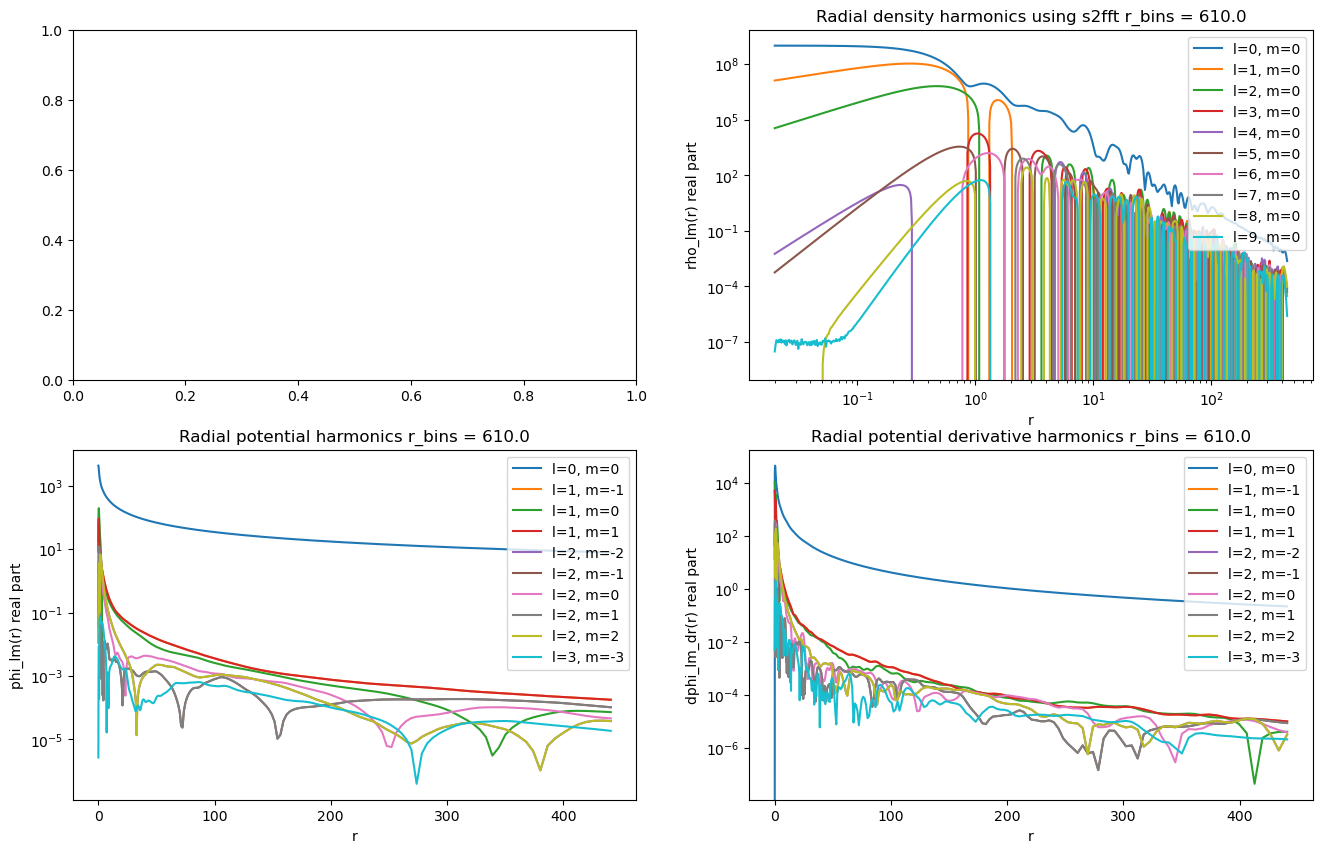

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0103%
    l=1, m=-1: max err = 0.0534%
    l=1, m=0: max err = 16.8959%
    l=1, m=1: max err = 0.0534%
    l=2, m=-2: max err = 2.7682%
    l=2, m=-1: max err = 0.2923%
    l=2, m=0: max err = 10.9605%
    l=2, m=1: max err = 0.2923%
    l=2, m=2: max err = 2.7682%
    l=3, m=-3: max err = 1.2705%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 1.0673%
    l=1, m=-1: max err = 1.1330%
    l=1, m=0: max err = 28.2957%
    l=1, m=1: max err = 1.1330%
    l=2, m=-2: max err = 28.2785%
    l=2, m=-1: max err = 21.2644%
    l=2, m=0: max err = 130.2301%
    l=2, m=1: max err = 21.2644%
    l=2, m=2: max err = 28.2785%
    l=3, m=-3: max err = 177.0199%
No. radius bins: 695.0


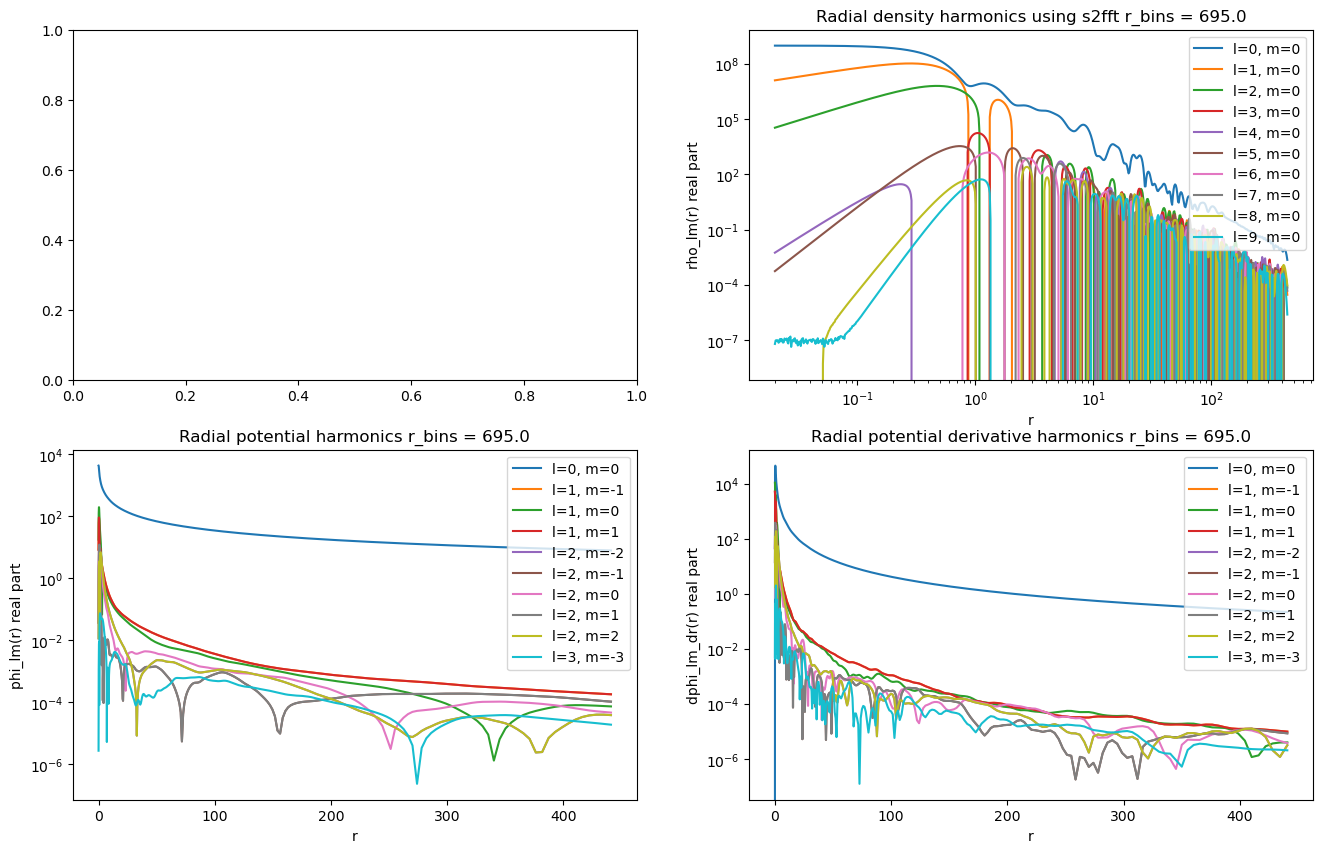

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0080%
    l=1, m=-1: max err = 0.0422%
    l=1, m=0: max err = 12.1143%
    l=1, m=1: max err = 0.0422%
    l=2, m=-2: max err = 2.0699%
    l=2, m=-1: max err = 0.2186%
    l=2, m=0: max err = 7.1793%
    l=2, m=1: max err = 0.2186%
    l=2, m=2: max err = 2.0699%
    l=3, m=-3: max err = 0.8979%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.8714%
    l=1, m=-1: max err = 0.9450%
    l=1, m=0: max err = 21.9394%
    l=1, m=1: max err = 0.9450%
    l=2, m=-2: max err = 27.6142%
    l=2, m=-1: max err = 16.1106%
    l=2, m=0: max err = 84.2642%
    l=2, m=1: max err = 16.1106%
    l=2, m=2: max err = 27.6142%
    l=3, m=-3: max err = 92.1687%
No. radius bins: 780.0


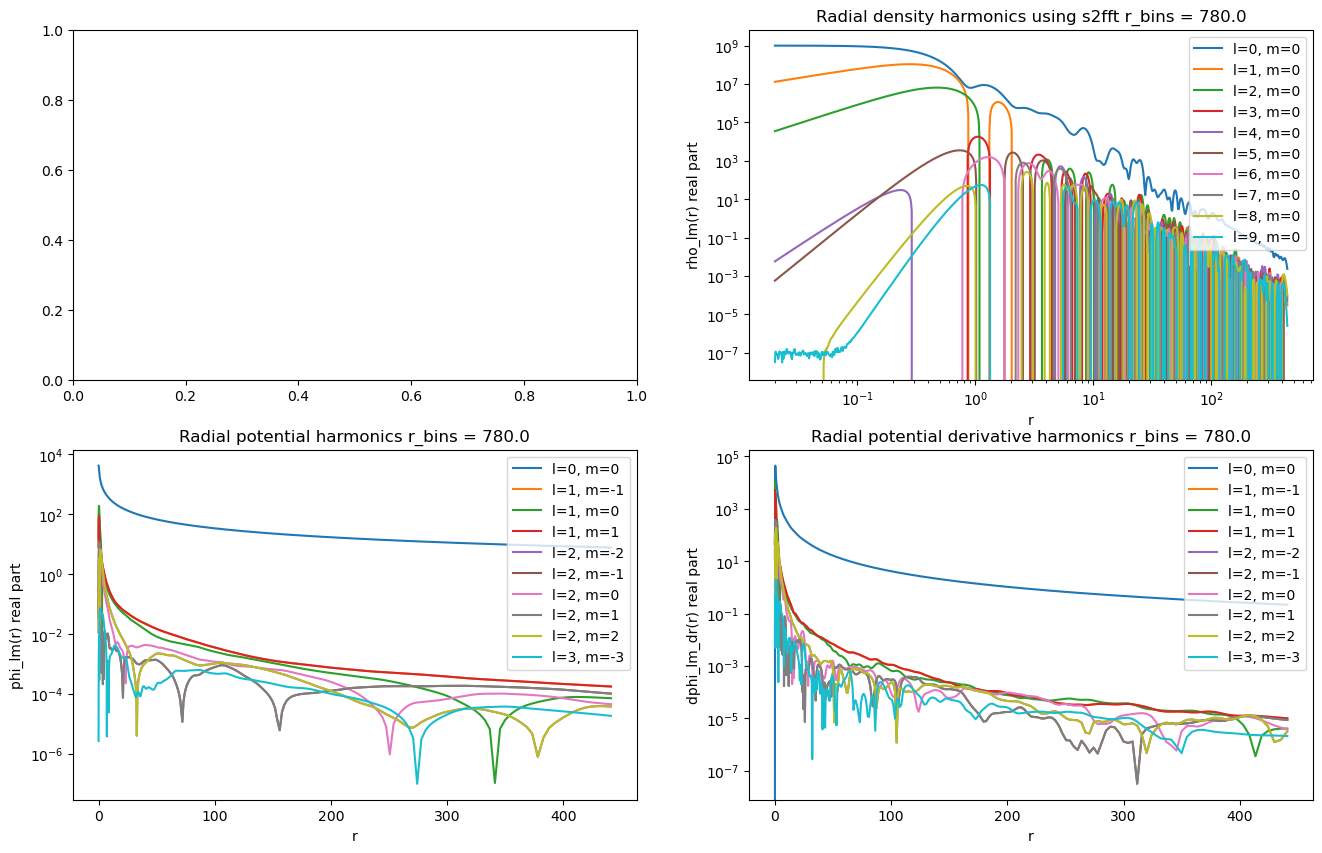

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0063%
    l=1, m=-1: max err = 0.0341%
    l=1, m=0: max err = 9.3003%
    l=1, m=1: max err = 0.0341%
    l=2, m=-2: max err = 1.6042%
    l=2, m=-1: max err = 0.1712%
    l=2, m=0: max err = 9.6972%
    l=2, m=1: max err = 0.1712%
    l=2, m=2: max err = 1.6042%
    l=3, m=-3: max err = 0.5538%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.7177%
    l=1, m=-1: max err = 0.8013%
    l=1, m=0: max err = 16.2885%
    l=1, m=1: max err = 0.8013%
    l=2, m=-2: max err = 21.3090%
    l=2, m=-1: max err = 12.4613%
    l=2, m=0: max err = 71.1638%
    l=2, m=1: max err = 12.4613%
    l=2, m=2: max err = 21.3090%
    l=3, m=-3: max err = 98.0401%
No. radius bins: 865.0


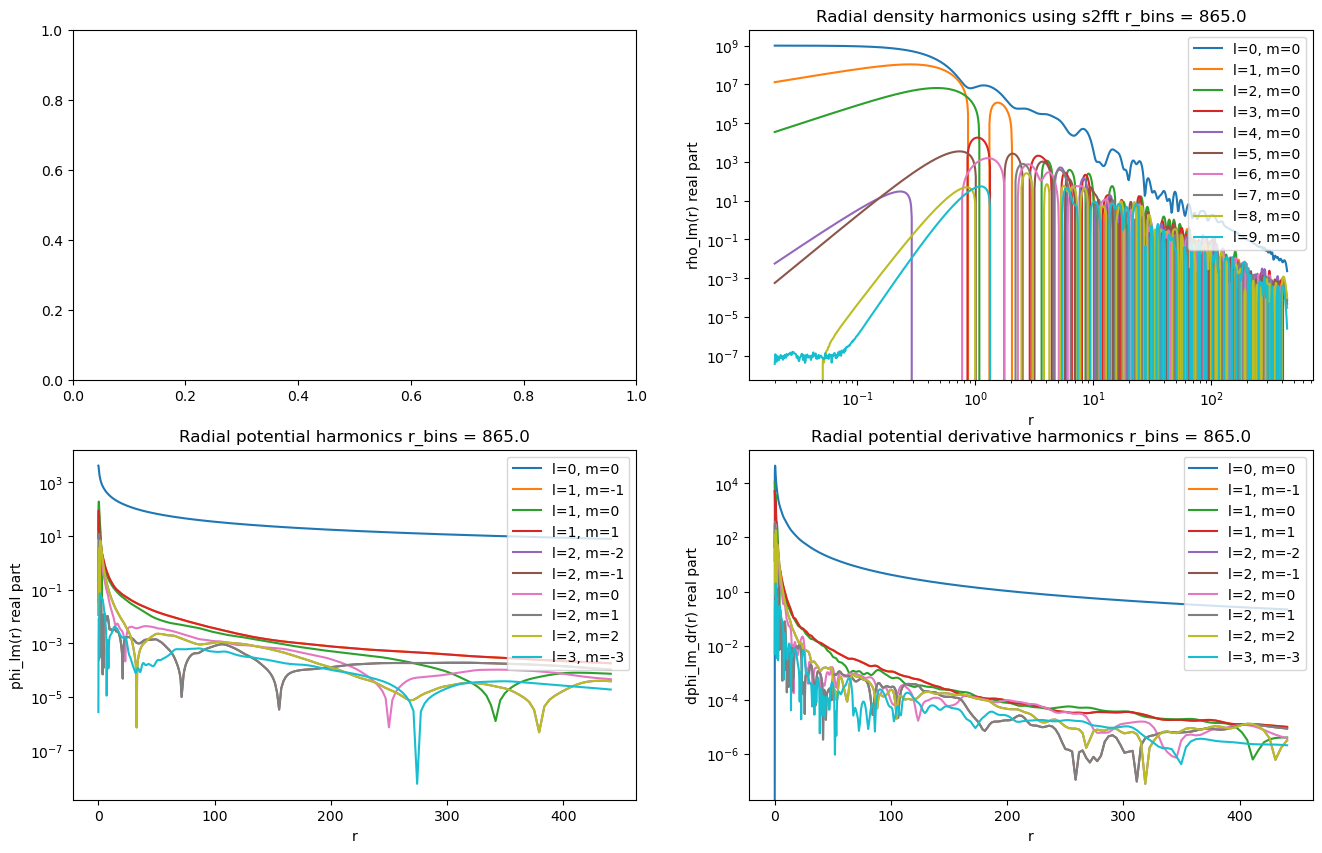

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0050%
    l=1, m=-1: max err = 0.0281%
    l=1, m=0: max err = 6.6721%
    l=1, m=1: max err = 0.0281%
    l=2, m=-2: max err = 1.2130%
    l=2, m=-1: max err = 0.1335%
    l=2, m=0: max err = 7.3513%
    l=2, m=1: max err = 0.1335%
    l=2, m=2: max err = 1.2130%
    l=3, m=-3: max err = 0.5784%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.5939%
    l=1, m=-1: max err = 0.6045%
    l=1, m=0: max err = 11.3121%
    l=1, m=1: max err = 0.6045%
    l=2, m=-2: max err = 15.0256%
    l=2, m=-1: max err = 9.7419%
    l=2, m=0: max err = 62.2340%
    l=2, m=1: max err = 9.7419%
    l=2, m=2: max err = 15.0256%
    l=3, m=-3: max err = 99.9762%
No. radius bins: 950.0


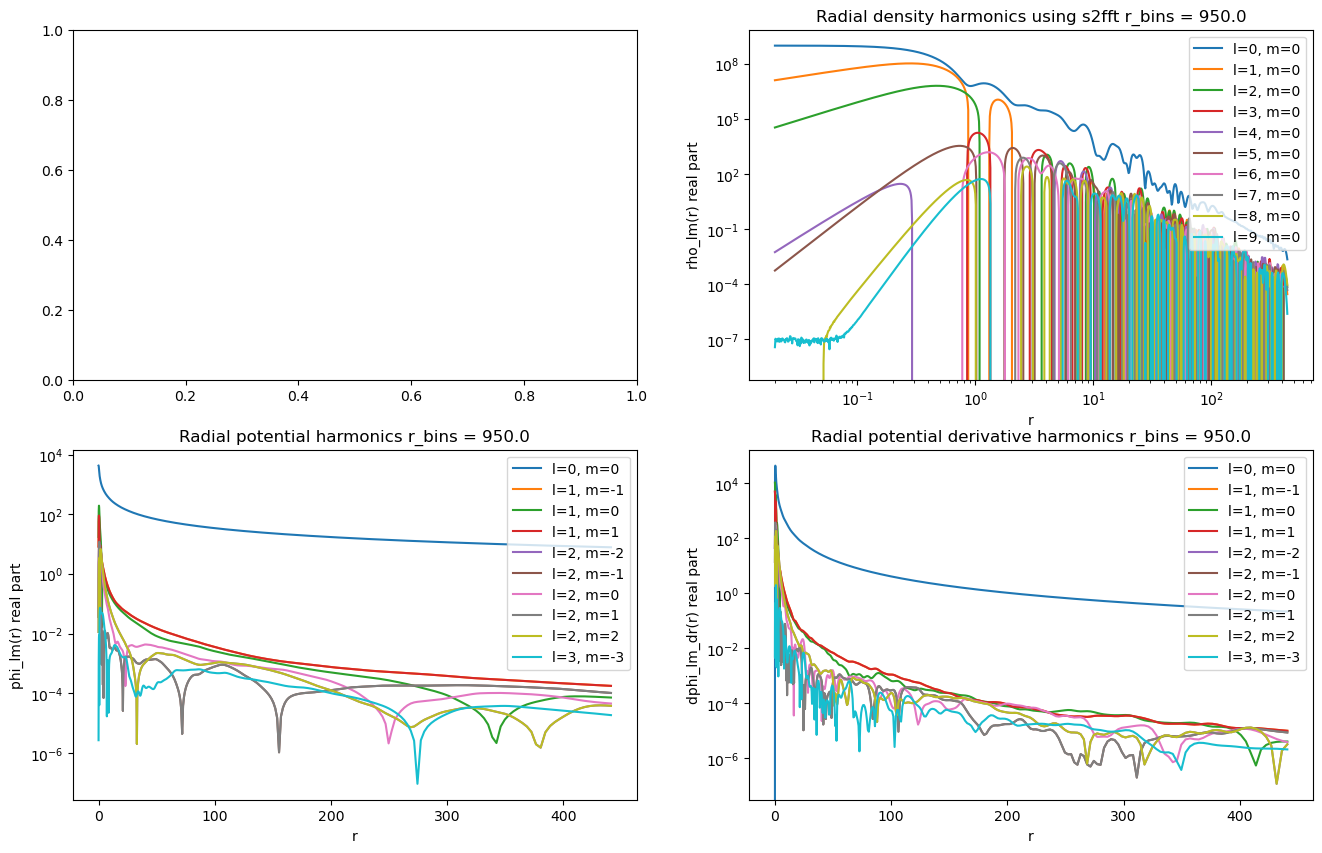

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0040%
    l=1, m=-1: max err = 0.0234%
    l=1, m=0: max err = 5.2539%
    l=1, m=1: max err = 0.0234%
    l=2, m=-2: max err = 0.9309%
    l=2, m=-1: max err = 0.1032%
    l=2, m=0: max err = 5.7261%
    l=2, m=1: max err = 0.1032%
    l=2, m=2: max err = 0.9309%
    l=3, m=-3: max err = 0.5617%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.4921%
    l=1, m=-1: max err = 0.5314%
    l=1, m=0: max err = 6.9572%
    l=1, m=1: max err = 0.5314%
    l=2, m=-2: max err = 12.0570%
    l=2, m=-1: max err = 7.6849%
    l=2, m=0: max err = 45.9470%
    l=2, m=1: max err = 7.6849%
    l=2, m=2: max err = 12.0570%
    l=3, m=-3: max err = 96.4278%
No. radius bins: 1035.0


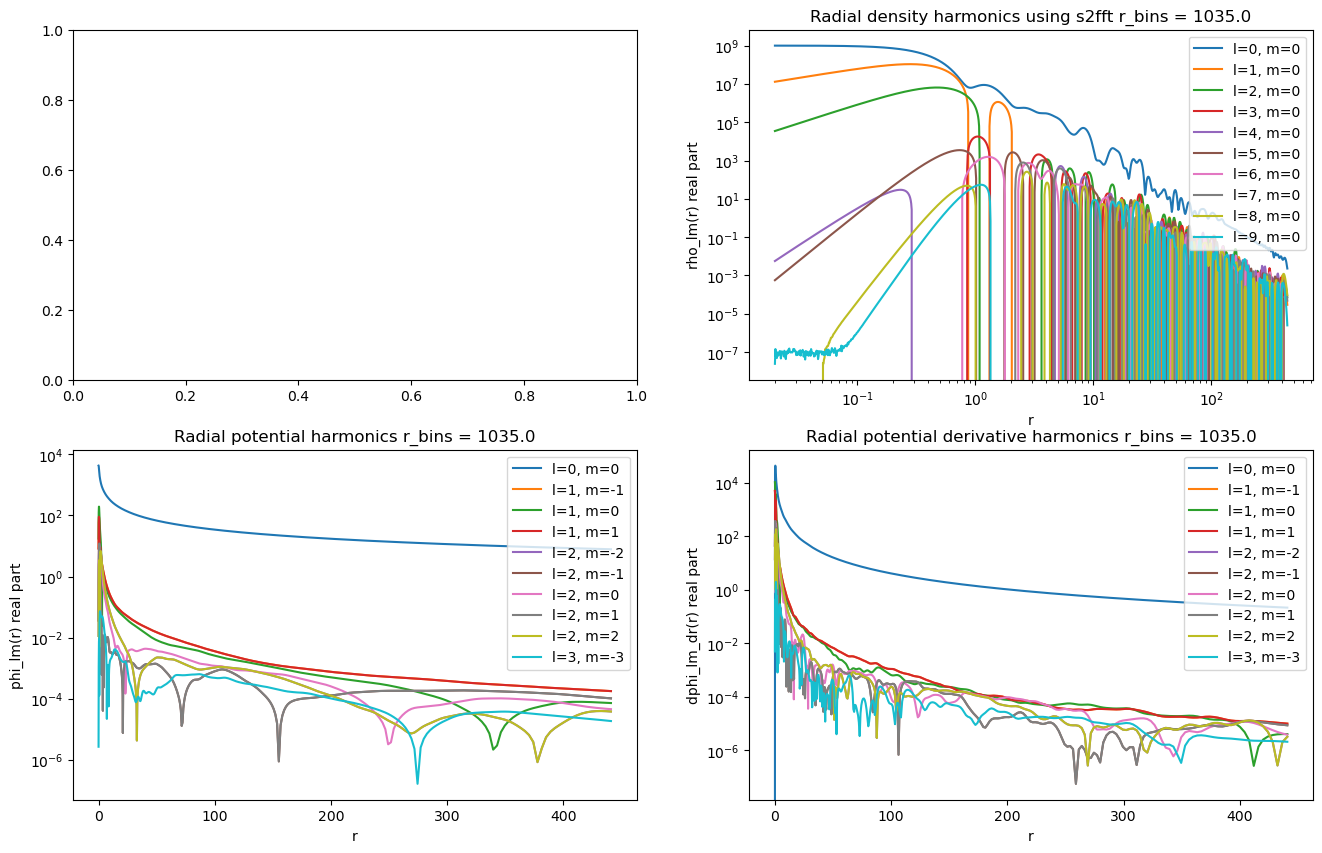

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0033%
    l=1, m=-1: max err = 0.0204%
    l=1, m=0: max err = 3.4639%
    l=1, m=1: max err = 0.0204%
    l=2, m=-2: max err = 0.7825%
    l=2, m=-1: max err = 0.0865%
    l=2, m=0: max err = 4.9862%
    l=2, m=1: max err = 0.0865%
    l=2, m=2: max err = 0.7825%
    l=3, m=-3: max err = 0.5234%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.4068%
    l=1, m=-1: max err = 0.4609%
    l=1, m=0: max err = 6.9788%
    l=1, m=1: max err = 0.4609%
    l=2, m=-2: max err = 9.1057%
    l=2, m=-1: max err = 6.0905%
    l=2, m=0: max err = 42.4534%
    l=2, m=1: max err = 6.0905%
    l=2, m=2: max err = 9.1057%
    l=3, m=-3: max err = 89.4770%
No. radius bins: 1120.0


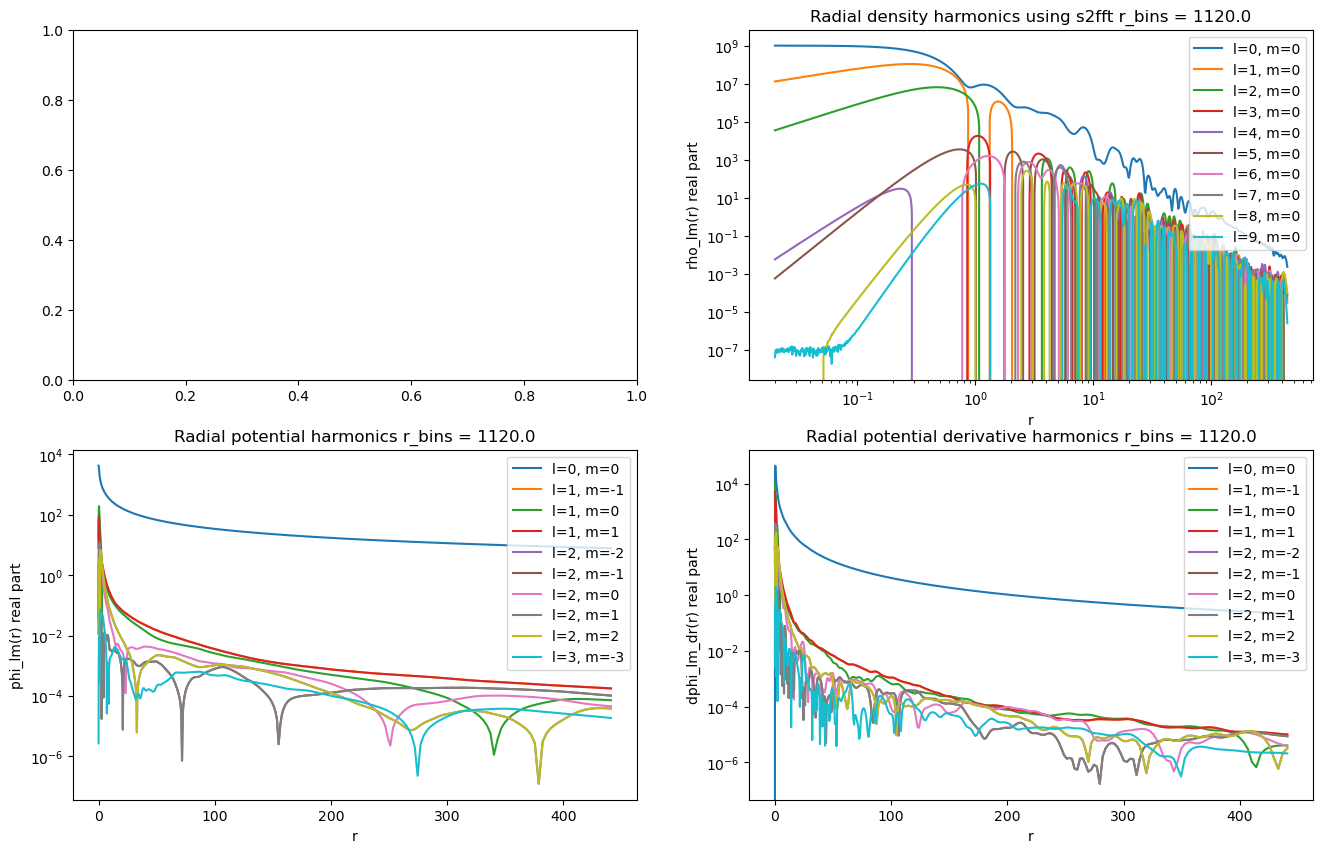

  phi_lm convergence (per mode):
    l=0, m=0: max err = 0.0028%
    l=1, m=-1: max err = 0.0179%
    l=1, m=0: max err = 4.5066%
    l=1, m=1: max err = 0.0179%
    l=2, m=-2: max err = 0.6508%
    l=2, m=-1: max err = 0.0708%
    l=2, m=0: max err = 5.1465%
    l=2, m=1: max err = 0.0708%
    l=2, m=2: max err = 0.6508%
    l=3, m=-3: max err = 0.4698%
  dphi_lm convergence (per mode):
    l=0, m=0: max err = 0.3344%
    l=1, m=-1: max err = 0.3947%
    l=1, m=0: max err = 3.8110%
    l=1, m=1: max err = 0.3947%
    l=2, m=-2: max err = 9.6837%
    l=2, m=-1: max err = 5.3400%
    l=2, m=0: max err = 37.4822%
    l=2, m=1: max err = 5.3400%
    l=2, m=2: max err = 9.6837%
    l=3, m=-3: max err = 80.4338%
No. radius bins: 1205.0


W0429 09:24:51.827864 3681651 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.94GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
E0429 09:24:51.827975 3681651 cuda_fft.cc:272] Failed to allocate work area.
E0429 09:24:51.827978 3681651 cuda_fft.cc:323] Initialize Params: rank: 1 elem_count: 572 input_embed: 572 input_stride: 1 input_distance: 572 output_embed: 572 output_stride: 1 output_distance: 572 batch_count: 344630
E0429 09:24:51.827984 3681651 cuda_fft.cc:332] Failed to initialize batched cufft plan with customized allocator: Out of memory while trying to allocate 2.94GiB.
E0429 09:24:51.829301 3681651 status_macros.cc:58] INTERNAL: RET_CHECK failure (external/xla/xla/backends/gpu/runtime/fft_thunk.cc:199) fft_plan != nullptr Failed to create cuFFT batched plan with scratch allocator
*** Begin stack trace ***
	
	
	
	
	
	
	
	
	
	
	
	

JaxRuntimeError: INTERNAL: RET_CHECK failure (external/xla/xla/backends/gpu/runtime/fft_thunk.cc:199) fft_plan != nullptr Failed to create cuFFT batched plan with scratch allocator

In [7]:
no_radius_bins = np.linspace(100, 1800, 21)
print(no_radius_bins)



for no_bins in no_radius_bins:
    print(f'No. radius bins: {no_bins}')
    r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), int(no_bins))


    R_j_r_fixed = eval_library(r, eigenstate_lib.radial_eigenmode_params)  # (Nr, Nj)


    phase = jnp.exp(-1j * eigen_energies * 1 * dt / 1)
    R_j_r_phased = R_j_r_fixed * phase[None, :]

    out_lm = [(L, M) for L in range(L_max_out) for M in range(-L, L+1)]
    output_lm_pairs = jnp.array(out_lm)


    # 1. Construct total psi and rho on background grid
    if m22 == 1:
        rho_lms = construct_rho_lms(aj, parent_j, R_j_r_phased, total_mass, L_max_out, gaunt_table, lm_idx_per_mode)

        print(rho_lms.shape)  # (Nr, L, 2L-1)

    rho_rtp = construct_rho_rtp(R_j_r_phased, aj, parent_j, Y_lm, lm_idx_per_mode)

    rho_lms_s2fft = forward_s2fft(rho_rtp, L_max_out)


    fig, ax = plt.subplots(2, 2, figsize=(16, 10))

    if m22 == 1:
        for l in range(0, 10):
            ax[0, 0].plot(r * u.to_Kpc, rho_lms[:, l, L_max_out - 1].real * u.to_Msun / u.to_Kpc ** 3, label = f'l={l}, m=0')

        ax[0, 0].set_xlabel('r')
        ax[0, 0].set_ylabel('rho_lm(r) real part')
        ax[0, 0].set_title(f'Radial density harmonics using gaunt r_bins = {no_bins}')
        ax[0, 0].set_yscale('log')
        ax[0, 0].set_xscale('log')
        ax[0, 0].legend()


    for l in range(0, 10):
        ax[0, 1].plot(r * u.to_Kpc, rho_lms_s2fft[:, l, L_max_out - 1].real * u.to_Msun / u.to_Kpc ** 3, label = f'l={l}, m=0')
    ax[0, 1].set_xlabel('r')
    ax[0, 1].set_ylabel('rho_lm(r) real part')
    ax[0, 1].set_title(f'Radial density harmonics using s2fft r_bins = {no_bins}')
    ax[0, 1].set_yscale('log')
    ax[0, 1].set_xscale('log')
    ax[0, 1].legend()


    G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

    if m22 == 1:

        dphi_lm, phi_lm = _compute_all_phi(rho_lms, r, output_lm_pairs, int(L_max_out), G)
    
    else:
        dphi_lm, phi_lm = _compute_all_phi(rho_lms_s2fft, r, output_lm_pairs, int(L_max_out), G)

    for lm in range(0, 10):
        ax[1, 0].plot(r * u.to_Kpc, abs(phi_lm[lm, :].real) * u.to_kms**2, label = f'l={output_lm_pairs[lm, 0]}, m={output_lm_pairs[lm, 1]}')
    ax[1, 0].set_xlabel('r')
    ax[1, 0].set_ylabel('phi_lm(r) real part')
    ax[1, 0].set_yscale('log')
    ax[1, 0].legend()
    ax[1, 0].set_title(f'Radial potential harmonics r_bins = {no_bins}')


    for lm in range(0, 10):
        ax[1, 1].plot(r * u.to_Kpc, abs(dphi_lm[lm, :].real) * u.to_kms**2, label = f'l={output_lm_pairs[lm, 0]}, m={output_lm_pairs[lm, 1]}')
    ax[1, 1].set_xlabel('r')
    ax[1, 1].set_ylabel('dphi_lm_dr(r) real part')
    
    ax[1, 1].set_yscale('log')
    ax[1, 1].legend()
    ax[1, 1].set_title(f'Radial potential derivative harmonics r_bins = {no_bins}')
    plt.show()


    # For each (l,m) mode, interpolate phi_lm from its coarse grid onto r_truth
    # phi_lm shape: (N_lm, Nr_coarse), r shape: (Nr_coarse,)
    phi_lm_interp = jax.vmap(lambda phi_mode: jnp.interp(r_truth, r, phi_mode.real))(phi_lm) \
                + 1j * jax.vmap(lambda phi_mode: jnp.interp(r_truth, r, phi_mode.imag))(phi_lm)
    
    d_phi_lm_interp = jax.vmap(lambda dphi_mode: jnp.interp(r_truth, r, dphi_mode.real))(dphi_lm) \
                + 1j * jax.vmap(lambda dphi_mode: jnp.interp(r_truth, r, dphi_mode.imag))(dphi_lm)
    

    # Per-mode convergence for dominant modes (masking near-zero truth values)
    print(f'  phi_lm convergence (per mode):')
    for lm_idx in range(min(10, len(output_lm_pairs))):
        mask = jnp.abs(phi_lm_2000[lm_idx]) > 1e-10 * jnp.max(jnp.abs(phi_lm_2000[lm_idx]))
        err = jnp.where(mask, 100 * jnp.abs(phi_lm_interp[lm_idx] - phi_lm_2000[lm_idx]) / jnp.abs(phi_lm_2000[lm_idx]), 0.0)
        print(f'    l={output_lm_pairs[lm_idx, 0]}, m={output_lm_pairs[lm_idx, 1]}: max err = {jnp.max(err):.4f}%')

    print(f'  dphi_lm convergence (per mode):')
    for lm_idx in range(min(10, len(output_lm_pairs))):
        mask = jnp.abs(dphi_lm_2000[lm_idx]) > 1e-10 * jnp.max(jnp.abs(dphi_lm_2000[lm_idx]))
        err = jnp.where(mask, 100 * jnp.abs(d_phi_lm_interp[lm_idx] - dphi_lm_2000[lm_idx]) / jnp.abs(dphi_lm_2000[lm_idx]), 0.0)
        print(f'    l={output_lm_pairs[lm_idx, 0]}, m={output_lm_pairs[lm_idx, 1]}: max err = {jnp.max(err):.4f}%')